# Taller Extraccion Caracteristicas SIFT ORB

Objetivo: implementar y comparar detectores de puntos clave y descriptores con SIFT y ORB, usando una imagen de prueba.

Notas:
- Dependencias: opencv-python, opencv-contrib-python, numpy, matplotlib.
- La imagen de entrada se lee desde media/ y los resultados se guardan en esa misma carpeta.

In [1]:
from pathlib import Path
from time import perf_counter
import csv

import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_NAME = "Imagen_taller_10_1.jpg"

def find_media_dir():
    candidates = [
        Path.cwd() / "media",
        Path.cwd().parent / "media",
        Path.cwd().parent.parent / "media",
        Path.cwd() / "semana_10_1_extraccion" / "media",
        Path.cwd().parent / "semana_10_1_extraccion" / "media",
        Path.cwd().parent / "Semana_10_Vision_Computador_Caracteristicas" / "semana_10_1_extraccion" / "media",
    ]
    for d in candidates:
        if (d / IMAGE_NAME).exists():
            return d
    raise FileNotFoundError(f"No se encontro {IMAGE_NAME}. Ajusta la ruta de media.")

MEDIA_DIR = find_media_dir()
MEDIA_DIR.mkdir(exist_ok=True)
IMAGE_PATH = MEDIA_DIR / IMAGE_NAME

img_bgr = cv2.imread(str(IMAGE_PATH))
if img_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Imagen cargada:", IMAGE_PATH)
print("Tamanio:", img_bgr.shape)

Imagen cargada: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\Imagen_taller_10_1.jpg
Tamanio: (480, 720, 3)


## Imagen de entrada
Se visualiza la imagen original para tener una referencia antes de aplicar los detectores.

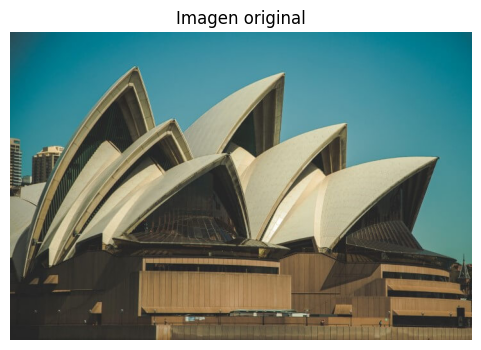

In [2]:
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Imagen original")
plt.show()

## Harris Corner Detector
Detecta esquinas usando el operador de Harris. Puedes ajustar blockSize, ksize y k para ver cambios en sensibilidad.

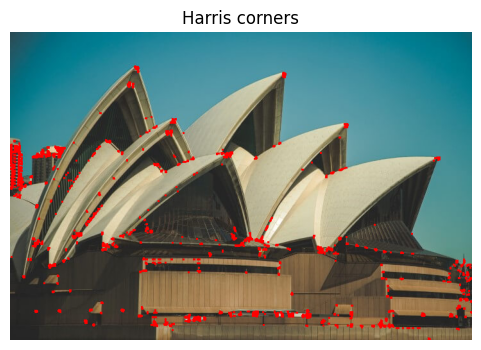

Guardado: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\harris_corners.png


In [3]:
def detect_harris(img_bgr, block_size=2, ksize=3, k=0.04, thresh_ratio=0.01):
    gray_f = np.float32(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY))
    dst = cv2.cornerHarris(gray_f, block_size, ksize, k)
    dst = cv2.dilate(dst, None)
    out = img_bgr.copy()
    out[dst > thresh_ratio * dst.max()] = [0, 0, 255]
    return out, dst

harris_bgr, harris_map = detect_harris(img_bgr)
harris_rgb = cv2.cvtColor(harris_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(harris_rgb)
plt.axis("off")
plt.title("Harris corners")
plt.show()

harris_out = MEDIA_DIR / "harris_corners.png"
cv2.imwrite(str(harris_out), harris_bgr)
print("Guardado:", harris_out)

## SIFT
SIFT detecta keypoints robustos a cambios de escala y rotacion. Requiere opencv-contrib-python.

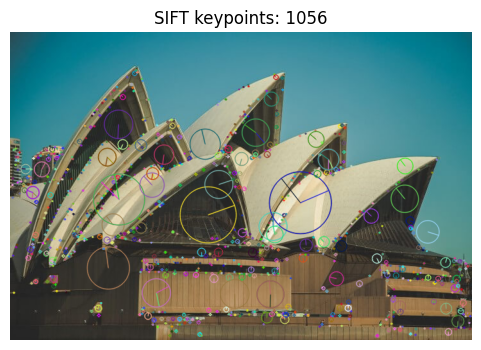

Guardado: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\sift_keypoints.png


In [4]:
try:
    sift = cv2.SIFT_create()
except AttributeError as exc:
    raise RuntimeError("SIFT no esta disponible. Instala opencv-contrib-python.") from exc

kp_sift, des_sift = sift.detectAndCompute(gray, None)
sift_draw = cv2.drawKeypoints(
    img_bgr, kp_sift, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(sift_draw, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"SIFT keypoints: {len(kp_sift)}")
plt.show()

sift_out = MEDIA_DIR / "sift_keypoints.png"
cv2.imwrite(str(sift_out), sift_draw)
print("Guardado:", sift_out)

## ORB
ORB combina FAST + BRIEF y es mas rapido que SIFT, con menor costo computacional.

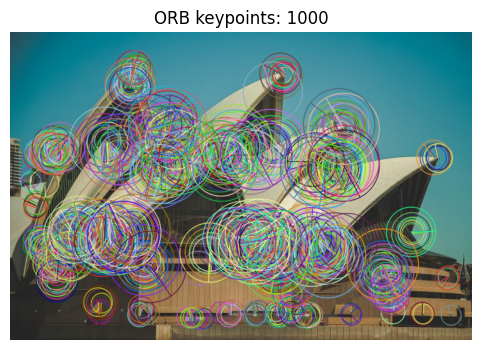

Guardado: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\orb_keypoints.png


In [5]:
orb = cv2.ORB_create(nfeatures=1000)
kp_orb, des_orb = orb.detectAndCompute(gray, None)
orb_draw = cv2.drawKeypoints(
    img_bgr, kp_orb, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(orb_draw, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"ORB keypoints: {len(kp_orb)}")
plt.show()

orb_out = MEDIA_DIR / "orb_keypoints.png"
cv2.imwrite(str(orb_out), orb_draw)
print("Guardado:", orb_out)

## Visualizacion lado a lado
Comparacion visual directa de la distribucion de keypoints en SIFT y ORB.

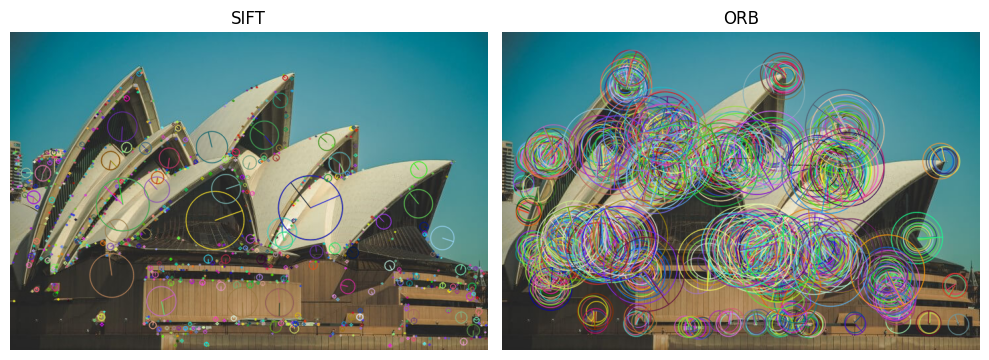

Guardado: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\sift_orb_side_by_side.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(sift_draw, cv2.COLOR_BGR2RGB))
axes[0].set_title("SIFT")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(orb_draw, cv2.COLOR_BGR2RGB))
axes[1].set_title("ORB")
axes[1].axis("off")
plt.tight_layout()
plt.show()

side_by_side_out = MEDIA_DIR / "sift_orb_side_by_side.png"
fig.savefig(side_by_side_out, dpi=150)
print("Guardado:", side_by_side_out)

## Comparacion de rendimiento
Se mide tiempo promedio y desviacion estandar en varias repeticiones y se guarda un CSV.

In [7]:
def time_detector(detector, gray_img, repeats=10):
    times = []
    last_kp = []
    for _ in range(repeats):
        t0 = perf_counter()
        last_kp, _ = detector.detectAndCompute(gray_img, None)
        t1 = perf_counter()
        times.append(t1 - t0)
    return float(np.mean(times)), float(np.std(times)), len(last_kp)

mean_sift, std_sift, n_sift = time_detector(sift, gray)
mean_orb, std_orb, n_orb = time_detector(orb, gray)

print("SIFT - mean(s):", mean_sift, "std(s):", std_sift, "keypoints:", n_sift)
print("ORB  - mean(s):", mean_orb, "std(s):", std_orb, "keypoints:", n_orb)

perf_out = MEDIA_DIR / "performance_summary.csv"
with open(perf_out, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["algorithm", "mean_s", "std_s", "keypoints"])
    writer.writerow(["SIFT", mean_sift, std_sift, n_sift])
    writer.writerow(["ORB", mean_orb, std_orb, n_orb])

print("Guardado:", perf_out)

SIFT - mean(s): 0.05735744999992676 std(s): 0.008465673200751322 keypoints: 1056
ORB  - mean(s): 0.004476700000122946 std(s): 0.0003406810591949776 keypoints: 1000
Guardado: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\performance_summary.csv


## Robustez ante rotacion, escala e iluminacion
Se generan versiones transformadas de la imagen y se compara el numero de keypoints.

In [8]:
def rotate_image(img, angle_deg):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    m = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    return cv2.warpAffine(img, m, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

def scale_image(img, scale):
    h, w = img.shape[:2]
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(resized, (w, h), interpolation=cv2.INTER_LINEAR)

def change_illumination(img, alpha=1.2, beta=20):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def count_kp(detector, img_bgr):
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kps, _ = detector.detectAndCompute(g, None)
    return len(kps)

tests = [
    ("original", img_bgr),
    ("rotate_30", rotate_image(img_bgr, 30)),
    ("rotate_60", rotate_image(img_bgr, 60)),
    ("scale_0_7", scale_image(img_bgr, 0.7)),
    ("scale_1_3", scale_image(img_bgr, 1.3)),
    ("illum_1_2_20", change_illumination(img_bgr, 1.2, 20)),
    ("illum_0_8_-20", change_illumination(img_bgr, 0.8, -20)),
]

rows = []
for name, img in tests:
    rows.append({
        "test": name,
        "sift_kp": count_kp(sift, img),
        "orb_kp": count_kp(orb, img),
    })

for r in rows:
    print(r)

robust_out = MEDIA_DIR / "robustness_summary.csv"
with open(robust_out, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["test", "sift_kp", "orb_kp"])
    for r in rows:
        writer.writerow([r["test"], r["sift_kp"], r["orb_kp"]])

print("Guardado:", robust_out)

{'test': 'original', 'sift_kp': 1056, 'orb_kp': 1000}
{'test': 'rotate_30', 'sift_kp': 1113, 'orb_kp': 1000}
{'test': 'rotate_60', 'sift_kp': 1082, 'orb_kp': 1000}
{'test': 'scale_0_7', 'sift_kp': 972, 'orb_kp': 1000}
{'test': 'scale_1_3', 'sift_kp': 1033, 'orb_kp': 1000}
{'test': 'illum_1_2_20', 'sift_kp': 1097, 'orb_kp': 1000}
{'test': 'illum_0_8_-20', 'sift_kp': 934, 'orb_kp': 993}
Guardado: c:\Users\Juant\OneDrive\Desktop\Juan\Universidad\Visual\Visual-Computing-2026\Semana_10_Vision_Computador_Caracteristicas\semana_10_1_extraccion\media\robustness_summary.csv


## Bonus: AKAZE y BRISK
Opcionales para explorar detectores adicionales y comparar cantidad de puntos clave.

In [9]:
akaze = cv2.AKAZE_create()
brisk = cv2.BRISK_create()

kp_akaze, _ = akaze.detectAndCompute(gray, None)
kp_brisk, _ = brisk.detectAndCompute(gray, None)

print("AKAZE keypoints:", len(kp_akaze))
print("BRISK keypoints:", len(kp_brisk))

AKAZE keypoints: 452
BRISK keypoints: 1070
